In [21]:
import os
from pathlib import Path

import geomulticorr as gmc

import xdem

# 1. Open `Session` for data manipulation

In [2]:
session = gmc.open_gmc_session("/home/cusicand/03_Data/GMC_projects/GMC_TEST", epsg_code=2154)

[ GMC ✓ ] : New GMC project: 'GMC_TEST'
[ GMC ✓ ] : Creating new GMC structure in: /home/cusicand/03_Data/GMC_projects/GMC_TEST
[ GMC 📄 ] : Default GMC-geodatabase template copied into /home/cusicand/03_Data/GMC_projects/GMC_TEST
[ GMC 📄 ] : Making a copy of 'GMC-QGIS-Mapset' template into /home/cusicand/03_Data/GMC_projects/GMC_TEST
[ GMC ✓ ] : Setting GMC folder structure
[ GMC 📁 ] : Creating 'raster_data_GMC_TEST' folder
[ GMC 🚀 ] : Session 'GMC_TEST' initialized.


In [3]:
raster_bank = session.map_georasters_bank("/home/cusicand/05_Devs/GeoMultiCorr/geomulticorr/data/french_alps/")

[ GMC 🔍 ] : Mapping georasters
|████████████████████████████████████████| 43/43 [100%] in 18.9s (2.19/s)        █▆▄ 23/43 [53%] in 17s (~16s, 1.3/s) 


In [4]:
raster_bank

,filename,sensor,xRes,yRes,bands,rows,cols,acq_date,file_path,sensor_family,sensor_platform,acq_datetime,src_crs,geometry
0,20180729_095421_1040_3B_AnalyticMS_SR_clip.tif,planetscope,3.0,3.0,4,1295,1741,2018-07-29,/home/cusicand/05_Devs/GeoMultiCorr/geomultico...,planetscope,planetscope,2018-07-29 09:54:21,EPSG:32632,"POLYGON ((1004014.911 6415593.685, 1004014.853..."
1,aerial-73-20010801-0980-6480-LA93-0M50-C070.tif,aerial,0.5,0.5,3,10000,10000,2001-08-01,/home/cusicand/05_Devs/GeoMultiCorr/geomultico...,aerial,aerial,2001-08-01 00:00:00,EPSG:2154,"POLYGON ((980000 6475000, 980000 6475001, 9800..."
2,20190713_102109_43_105c_3B_AnalyticMS_SR_clip.tif,planetscope,3.0,3.0,4,1295,1741,2019-07-13,/home/cusicand/05_Devs/GeoMultiCorr/geomultico...,planetscope,planetscope,2019-07-13 10:21:09,EPSG:32632,"POLYGON ((1004014.911 6415593.685, 1004014.853..."
3,20160816_093503_0e0f_3B_AnalyticMS_SR_clip.tif,planetscope,3.0,3.0,4,1295,1741,2016-08-16,/home/cusicand/05_Devs/GeoMultiCorr/geomultico...,planetscope,planetscope,2016-08-16 09:35:03,EPSG:32632,"POLYGON ((1004014.911 6415593.685, 1004014.853..."
4,20160816_093503_0e0f_3B_udm2_clip.tif,planetscope,3.0,3.0,8,1295,1741,2016-08-16,/home/cusicand/05_Devs/GeoMultiCorr/geomultico...,planetscope,planetscope,2016-08-16 09:35:03,EPSG:32632,"POLYGON ((1004014.911 6415593.685, 1004014.853..."
5,20240708_104303_88_2486_3B_udm2_clip.tif,planetscope,3.0,3.0,8,1295,1741,2024-07-08,/home/cusicand/05_Devs/GeoMultiCorr/geomultico...,planetscope,planetscope,2024-07-08 10:43:03,EPSG:32632,"POLYGON ((1004014.911 6415593.685, 1004014.853..."
6,20200725_103349_66_1066_3B_AnalyticMS_SR_clip.tif,planetscope,3.0,3.0,4,1295,1741,2020-07-25,/home/cusicand/05_Devs/GeoMultiCorr/geomultico...,planetscope,planetscope,2020-07-25 10:33:49,EPSG:32632,"POLYGON ((1004014.911 6415593.685, 1004014.853..."
7,20180729_095421_1040_3B_udm2_clip.tif,planetscope,3.0,3.0,8,1295,1741,2018-07-29,/home/cusicand/05_Devs/GeoMultiCorr/geomultico...,planetscope,planetscope,2018-07-29 09:54:21,EPSG:32632,"POLYGON ((1004014.911 6415593.685, 1004014.853..."
8,20210710_102538_96_2416_3B_udm2_clip.tif,planetscope,3.0,3.0,8,1295,1741,2021-07-10,/home/cusicand/05_Devs/GeoMultiCorr/geomultico...,planetscope,planetscope,2021-07-10 10:25:38,EPSG:32632,"POLYGON ((1004014.911 6415593.685, 1004014.853..."
9,20250716_105532_47_252e_3B_AnalyticMS_SR_clip.tif,planetscope,3.0,3.0,4,1295,1741,2025-07-16,/home/cusicand/05_Devs/GeoMultiCorr/geomultico...,planetscope,planetscope,2025-07-16 10:55:32,EPSG:32632,"POLYGON ((1004014.911 6415593.685, 1004014.853..."


<Axes: >

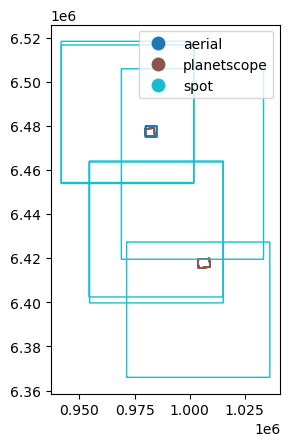

In [5]:
raster_bank.plot(
    column="sensor_family",
    categorical=True,
    facecolor="none",
    legend=True,
)

In [6]:
selected_rasters = raster_bank[
    raster_bank["sensor_family"].isin(["planetscope"])
]

In [7]:
selected_rasters

,filename,sensor,xRes,yRes,bands,rows,cols,acq_date,file_path,sensor_family,sensor_platform,acq_datetime,src_crs,geometry
0,20180729_095421_1040_3B_AnalyticMS_SR_clip.tif,planetscope,3.0,3.0,4,1295,1741,2018-07-29,/home/cusicand/05_Devs/GeoMultiCorr/geomultico...,planetscope,planetscope,2018-07-29 09:54:21,EPSG:32632,"POLYGON ((1004014.911 6415593.685, 1004014.853..."
2,20190713_102109_43_105c_3B_AnalyticMS_SR_clip.tif,planetscope,3.0,3.0,4,1295,1741,2019-07-13,/home/cusicand/05_Devs/GeoMultiCorr/geomultico...,planetscope,planetscope,2019-07-13 10:21:09,EPSG:32632,"POLYGON ((1004014.911 6415593.685, 1004014.853..."
3,20160816_093503_0e0f_3B_AnalyticMS_SR_clip.tif,planetscope,3.0,3.0,4,1295,1741,2016-08-16,/home/cusicand/05_Devs/GeoMultiCorr/geomultico...,planetscope,planetscope,2016-08-16 09:35:03,EPSG:32632,"POLYGON ((1004014.911 6415593.685, 1004014.853..."
4,20160816_093503_0e0f_3B_udm2_clip.tif,planetscope,3.0,3.0,8,1295,1741,2016-08-16,/home/cusicand/05_Devs/GeoMultiCorr/geomultico...,planetscope,planetscope,2016-08-16 09:35:03,EPSG:32632,"POLYGON ((1004014.911 6415593.685, 1004014.853..."
5,20240708_104303_88_2486_3B_udm2_clip.tif,planetscope,3.0,3.0,8,1295,1741,2024-07-08,/home/cusicand/05_Devs/GeoMultiCorr/geomultico...,planetscope,planetscope,2024-07-08 10:43:03,EPSG:32632,"POLYGON ((1004014.911 6415593.685, 1004014.853..."
6,20200725_103349_66_1066_3B_AnalyticMS_SR_clip.tif,planetscope,3.0,3.0,4,1295,1741,2020-07-25,/home/cusicand/05_Devs/GeoMultiCorr/geomultico...,planetscope,planetscope,2020-07-25 10:33:49,EPSG:32632,"POLYGON ((1004014.911 6415593.685, 1004014.853..."
7,20180729_095421_1040_3B_udm2_clip.tif,planetscope,3.0,3.0,8,1295,1741,2018-07-29,/home/cusicand/05_Devs/GeoMultiCorr/geomultico...,planetscope,planetscope,2018-07-29 09:54:21,EPSG:32632,"POLYGON ((1004014.911 6415593.685, 1004014.853..."
8,20210710_102538_96_2416_3B_udm2_clip.tif,planetscope,3.0,3.0,8,1295,1741,2021-07-10,/home/cusicand/05_Devs/GeoMultiCorr/geomultico...,planetscope,planetscope,2021-07-10 10:25:38,EPSG:32632,"POLYGON ((1004014.911 6415593.685, 1004014.853..."
9,20250716_105532_47_252e_3B_AnalyticMS_SR_clip.tif,planetscope,3.0,3.0,4,1295,1741,2025-07-16,/home/cusicand/05_Devs/GeoMultiCorr/geomultico...,planetscope,planetscope,2025-07-16 10:55:32,EPSG:32632,"POLYGON ((1004014.911 6415593.685, 1004014.853..."
10,20170703_094023_0f4e_3B_AnalyticMS_SR_clip.tif,planetscope,3.0,3.0,4,1295,1741,2017-07-03,/home/cusicand/05_Devs/GeoMultiCorr/geomultico...,planetscope,planetscope,2017-07-03 09:40:23,EPSG:32632,"POLYGON ((1004014.911 6415593.685, 1004014.853..."


# 2. Drawing `PZONE` manually or in QGIS

## 2.1. Option A — draw interactively on a map:

In [8]:
# Draw your polygon on the map, then run the next cell:
get_gdf = session.draw_polygon_manually(raster_bank=raster_bank)

Map(center=[46.8, 8.2], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title', 'zoom_out_…

Draw your polygon(s) on the map above. When done, run the next cell to get the GeoDataFrame.


In [9]:
aoi = get_gdf()
session.insert_pzone(aoi.geometry.iloc[0], pz_name="PasDeLours", pz_shortname="PDL")

[ GMC ✓ ] : Pzone 'PasDeLours' inserted.


In [10]:
session.get_pzones_overview()

,pz_name,pz_shortname,pz_surf,geometry
0,PasDeLours,PDL,None,"POLYGON ((1004118.041 6415890.779, 1003951.383..."


## 2.2. Option B — load from a vector file:

In [12]:
# TODO: add aoi to the session, from external dawn.

# 3. Crop data using `PZONE` extent

In [13]:
session.sieve_bulk(selected_rasters,
                   target_resolution=3)

[ GMC 📋 ] : Map epsg : EPSG:2154
Pzone epsg : EPSG:2154
[ GMC 📋 ] : Target resolution: 3 (EPSG:2154)
[ GMC 📋 ] : Pzone: PasDeLours
[ GMC 📋 ] : Intersecting rasters: 22
Cropping PasDeLours_2016-08-16_planetscope.tif |████████████████████████████████
[ GMC 📋 ] : Merging 2 tiles for PasDeLours_2016-08-16_planetscope.tif


/home/cusicand/micromamba/envs/gmc_env/lib/python3.12/site-packages/geoutils/raster/raster.py:1702: UserWarning: New nodata value cells already exist in the data array. These cells will now be masked, and the old nodata value cells will update to the same new value. Use set_nodata() with update_array=False or update_mask=False to change this behaviour.
  warnings.warn(


[ GMC 💾 ] : Saved: /home/cusicand/03_Data/GMC_projects/GMC_TEST/raster_data_GMC_TEST/PasDeLours/opticals/PasDeLours_2016-08-16_planetscope.tif
Cropping PasDeLours_2017-07-03_planetscope.tif |████████████████████████████████
[ GMC 📋 ] : Merging 2 tiles for PasDeLours_2017-07-03_planetscope.tif


/home/cusicand/micromamba/envs/gmc_env/lib/python3.12/site-packages/geoutils/raster/raster.py:1702: UserWarning: New nodata value cells already exist in the data array. These cells will now be masked, and the old nodata value cells will update to the same new value. Use set_nodata() with update_array=False or update_mask=False to change this behaviour.
  warnings.warn(


[ GMC 💾 ] : Saved: /home/cusicand/03_Data/GMC_projects/GMC_TEST/raster_data_GMC_TEST/PasDeLours/opticals/PasDeLours_2017-07-03_planetscope.tif
Cropping PasDeLours_2017-07-13_planetscope.tif |████████████████████████████████
[ GMC 📋 ] : Merging 2 tiles for PasDeLours_2017-07-13_planetscope.tif


...

/home/cusicand/micromamba/envs/gmc_env/lib/python3.12/site-packages/geoutils/raster/raster.py:1702: UserWarning: New nodata value cells already exist in the data array. These cells will now be masked, and the old nodata value cells will update to the same new value. Use set_nodata() with update_array=False or update_mask=False to change this behaviour.
  warnings.warn(


[ GMC 💾 ] : Saved: /home/cusicand/03_Data/GMC_projects/GMC_TEST/raster_data_GMC_TEST/PasDeLours/opticals/PasDeLours_2024-07-08_planetscope.tif
Cropping PasDeLours_2025-07-16_planetscope.tif |████████████████████████████████
[ GMC 📋 ] : Merging 2 tiles for PasDeLours_2025-07-16_planetscope.tif


/home/cusicand/micromamba/envs/gmc_env/lib/python3.12/site-packages/geoutils/raster/raster.py:1702: UserWarning: New nodata value cells already exist in the data array. These cells will now be masked, and the old nodata value cells will update to the same new value. Use set_nodata() with update_array=False or update_mask=False to change this behaviour.
  warnings.warn(


[ GMC 💾 ] : Saved: /home/cusicand/03_Data/GMC_projects/GMC_TEST/raster_data_GMC_TEST/PasDeLours/opticals/PasDeLours_2025-07-16_planetscope.tif


{'PasDeLours': [PosixPath('/home/cusicand/03_Data/GMC_projects/GMC_TEST/raster_data_GMC_TEST/PasDeLours/opticals/PasDeLours_2016-08-16_planetscope.tif'),
  PosixPath('/home/cusicand/03_Data/GMC_projects/GMC_TEST/raster_data_GMC_TEST/PasDeLours/opticals/PasDeLours_2017-07-03_planetscope.tif'),
  PosixPath('/home/cusicand/03_Data/GMC_projects/GMC_TEST/raster_data_GMC_TEST/PasDeLours/opticals/PasDeLours_2017-07-13_planetscope.tif'),
  PosixPath('/home/cusicand/03_Data/GMC_projects/GMC_TEST/raster_data_GMC_TEST/PasDeLours/opticals/PasDeLours_2018-07-29_planetscope.tif'),
  PosixPath('/home/cusicand/03_Data/GMC_projects/GMC_TEST/raster_data_GMC_TEST/PasDeLours/opticals/PasDeLours_2019-07-13_planetscope.tif'),
  PosixPath('/home/cusicand/03_Data/GMC_projects/GMC_TEST/raster_data_GMC_TEST/PasDeLours/opticals/PasDeLours_2020-07-25_planetscope.tif'),
  PosixPath('/home/cusicand/03_Data/GMC_projects/GMC_TEST/raster_data_GMC_TEST/PasDeLours/opticals/PasDeLours_2021-07-10_planetscope.tif'),
  Posi

# 4. Register `Thumbs`

In [14]:
session.update_thumbs()
session.get_thumbs_overview()  # check

/home/cusicand/micromamba/envs/gmc_env/lib/python3.12/site-packages/geopandas/array.py:1770: UserWarning: CRS not set for some of the concatenation inputs. Setting output's CRS as RGF93 v1 / Lambert-93 (the single non-null crs provided).
  return GeometryArray(data, crs=_get_common_crs(to_concat))


,th_pz_name,th_path,th_sensor,th_date,th_year,th_valid,geometry,th_date_dec,th_date_datetime
0,PasDeLours,/home/cusicand/03_Data/GMC_projects/GMC_TEST/r...,planetscope,2017-07-13,2017,0,"POLYGON ((1003950 6415890, 1003950 6415890.733...",2017.500000,2017-07-13
1,PasDeLours,/home/cusicand/03_Data/GMC_projects/GMC_TEST/r...,planetscope,2025-07-16,2025,0,"POLYGON ((1003950 6415890, 1003950 6415890.733...",2025.500000,2025-07-16
2,PasDeLours,/home/cusicand/03_Data/GMC_projects/GMC_TEST/r...,planetscope,2023-07-17,2023,0,"POLYGON ((1003950 6415890, 1003950 6415890.733...",2023.500000,2023-07-17
3,PasDeLours,/home/cusicand/03_Data/GMC_projects/GMC_TEST/r...,planetscope,2024-07-08,2024,0,"POLYGON ((1003950 6415890, 1003950 6415890.733...",2024.500000,2024-07-08
4,PasDeLours,/home/cusicand/03_Data/GMC_projects/GMC_TEST/r...,planetscope,2021-07-10,2021,0,"POLYGON ((1003950 6415890, 1003950 6415890.733...",2021.500000,2021-07-10
5,PasDeLours,/home/cusicand/03_Data/GMC_projects/GMC_TEST/r...,planetscope,2017-07-03,2017,0,"POLYGON ((1003950 6415890, 1003950 6415890.733...",2017.500000,2017-07-03
6,PasDeLours,/home/cusicand/03_Data/GMC_projects/GMC_TEST/r...,planetscope,2022-07-22,2022,0,"POLYGON ((1003950 6415890, 1003950 6415890.733...",2022.500000,2022-07-22
7,PasDeLours,/home/cusicand/03_Data/GMC_projects/GMC_TEST/r...,planetscope,2016-08-16,2016,0,"POLYGON ((1003950 6415890, 1003950 6415890.733...",2016.583333,2016-08-16
8,PasDeLours,/home/cusicand/03_Data/GMC_projects/GMC_TEST/r...,planetscope,2019-07-13,2019,0,"POLYGON ((1003950 6415890, 1003950 6415890.733...",2019.500000,2019-07-13
9,PasDeLours,/home/cusicand/03_Data/GMC_projects/GMC_TEST/r...,planetscope,2020-07-25,2020,0,"POLYGON ((1003950 6415890, 1003950 6415890.733...",2020.500000,2020-07-25


# 4.1. Validate `Thumbs`

## 4.1.1. Validate all `Thumbs`

In [15]:
session.validate_all_thumbs()

,th_pz_name,th_path,th_sensor,th_date,th_year,th_valid,geometry,th_date_dec,th_date_datetime
0,PasDeLours,/home/cusicand/03_Data/GMC_projects/GMC_TEST/r...,planetscope,2017-07-13,2017,1,"POLYGON ((1003950 6415890, 1003950 6415890.733...",2017.500000,2017-07-13
1,PasDeLours,/home/cusicand/03_Data/GMC_projects/GMC_TEST/r...,planetscope,2025-07-16,2025,1,"POLYGON ((1003950 6415890, 1003950 6415890.733...",2025.500000,2025-07-16
2,PasDeLours,/home/cusicand/03_Data/GMC_projects/GMC_TEST/r...,planetscope,2023-07-17,2023,1,"POLYGON ((1003950 6415890, 1003950 6415890.733...",2023.500000,2023-07-17
3,PasDeLours,/home/cusicand/03_Data/GMC_projects/GMC_TEST/r...,planetscope,2024-07-08,2024,1,"POLYGON ((1003950 6415890, 1003950 6415890.733...",2024.500000,2024-07-08
4,PasDeLours,/home/cusicand/03_Data/GMC_projects/GMC_TEST/r...,planetscope,2021-07-10,2021,1,"POLYGON ((1003950 6415890, 1003950 6415890.733...",2021.500000,2021-07-10
5,PasDeLours,/home/cusicand/03_Data/GMC_projects/GMC_TEST/r...,planetscope,2017-07-03,2017,1,"POLYGON ((1003950 6415890, 1003950 6415890.733...",2017.500000,2017-07-03
6,PasDeLours,/home/cusicand/03_Data/GMC_projects/GMC_TEST/r...,planetscope,2022-07-22,2022,1,"POLYGON ((1003950 6415890, 1003950 6415890.733...",2022.500000,2022-07-22
7,PasDeLours,/home/cusicand/03_Data/GMC_projects/GMC_TEST/r...,planetscope,2016-08-16,2016,1,"POLYGON ((1003950 6415890, 1003950 6415890.733...",2016.583333,2016-08-16
8,PasDeLours,/home/cusicand/03_Data/GMC_projects/GMC_TEST/r...,planetscope,2019-07-13,2019,1,"POLYGON ((1003950 6415890, 1003950 6415890.733...",2019.500000,2019-07-13
9,PasDeLours,/home/cusicand/03_Data/GMC_projects/GMC_TEST/r...,planetscope,2020-07-25,2020,1,"POLYGON ((1003950 6415890, 1003950 6415890.733...",2020.500000,2020-07-25


## 4.1.2. Validate specific `Thumbs`

In [16]:
# TODO: validate thumbs by criteria (e.g. we know which are the best ones, so we can validate only those, and not all)

## 4.1.3. Validate `Thumbs` based on `dt` criterias

In [17]:
# TODO: validate only those thumbs base don dt criteria

# 5. Generate `Pairs`

In [18]:
session.update_pairs_with_strategy(
    strategy="redundancy",  # or "sequential"
    max_step=1,             # 1 = adjacent pairs only; 2 = skip-one, etc.
)

[ GMC 📋 ] : Updating pairs for PZone: 'PasDeLours'


,pa_pz_name,pa_path,pa_left_date,pa_left_sensor,pa_right_date,pa_right_sensor,pa_dt_days,pa_dt_months,pa_dt_years,pa_direction,pa_magn_path,pa_disparity_rd_path,pa_disparity_f_path,pa_status,pa_ew_path,pa_ns_path,pa_cc_path,geometry
0,PasDeLours,/home/cusicand/03_Data/GMC_projects/GMC_TEST/r...,2016-08-16,planetscope,2017-07-03,planetscope,321,10.55,0.8789,forward,/home/cusicand/03_Data/GMC_projects/GMC_TEST/r...,/home/cusicand/03_Data/GMC_projects/GMC_TEST/r...,/home/cusicand/03_Data/GMC_projects/GMC_TEST/r...,empty,/home/cusicand/03_Data/GMC_projects/GMC_TEST/r...,/home/cusicand/03_Data/GMC_projects/GMC_TEST/r...,/home/cusicand/03_Data/GMC_projects/GMC_TEST/r...,"POLYGON ((1003950 6415890, 1003950 6415890.733..."
1,PasDeLours,/home/cusicand/03_Data/GMC_projects/GMC_TEST/r...,2017-07-03,planetscope,2016-08-16,planetscope,321,10.55,0.8789,backward,/home/cusicand/03_Data/GMC_projects/GMC_TEST/r...,/home/cusicand/03_Data/GMC_projects/GMC_TEST/r...,/home/cusicand/03_Data/GMC_projects/GMC_TEST/r...,empty,/home/cusicand/03_Data/GMC_projects/GMC_TEST/r...,/home/cusicand/03_Data/GMC_projects/GMC_TEST/r...,/home/cusicand/03_Data/GMC_projects/GMC_TEST/r...,"POLYGON ((1003950 6415890, 1003950 6415890.733..."
2,PasDeLours,/home/cusicand/03_Data/GMC_projects/GMC_TEST/r...,2017-07-03,planetscope,2017-07-13,planetscope,10,0.33,0.0274,forward,/home/cusicand/03_Data/GMC_projects/GMC_TEST/r...,/home/cusicand/03_Data/GMC_projects/GMC_TEST/r...,/home/cusicand/03_Data/GMC_projects/GMC_TEST/r...,empty,/home/cusicand/03_Data/GMC_projects/GMC_TEST/r...,/home/cusicand/03_Data/GMC_projects/GMC_TEST/r...,/home/cusicand/03_Data/GMC_projects/GMC_TEST/r...,"POLYGON ((1003950 6415890, 1003950 6415890.733..."
3,PasDeLours,/home/cusicand/03_Data/GMC_projects/GMC_TEST/r...,2017-07-13,planetscope,2017-07-03,planetscope,10,0.33,0.0274,backward,/home/cusicand/03_Data/GMC_projects/GMC_TEST/r...,/home/cusicand/03_Data/GMC_projects/GMC_TEST/r...,/home/cusicand/03_Data/GMC_projects/GMC_TEST/r...,empty,/home/cusicand/03_Data/GMC_projects/GMC_TEST/r...,/home/cusicand/03_Data/GMC_projects/GMC_TEST/r...,/home/cusicand/03_Data/GMC_projects/GMC_TEST/r...,"POLYGON ((1003950 6415890, 1003950 6415890.733..."
4,PasDeLours,/home/cusicand/03_Data/GMC_projects/GMC_TEST/r...,2017-07-13,planetscope,2018-07-29,planetscope,381,12.52,1.0431,forward,/home/cusicand/03_Data/GMC_projects/GMC_TEST/r...,/home/cusicand/03_Data/GMC_projects/GMC_TEST/r...,/home/cusicand/03_Data/GMC_projects/GMC_TEST/r...,empty,/home/cusicand/03_Data/GMC_projects/GMC_TEST/r...,/home/cusicand/03_Data/GMC_projects/GMC_TEST/r...,/home/cusicand/03_Data/GMC_projects/GMC_TEST/r...,"POLYGON ((1003950 6415890, 1003950 6415890.733..."
5,PasDeLours,/home/cusicand/03_Data/GMC_projects/GMC_TEST/r...,2018-07-29,planetscope,2017-07-13,planetscope,381,12.52,1.0431,backward,/home/cusicand/03_Data/GMC_projects/GMC_TEST/r...,/home/cusicand/03_Data/GMC_projects/GMC_TEST/r...,/home/cusicand/03_Data/GMC_projects/GMC_TEST/r...,empty,/home/cusicand/03_Data/GMC_projects/GMC_TEST/r...,/home/cusicand/03_Data/GMC_projects/GMC_TEST/r...,/home/cusicand/03_Data/GMC_projects/GMC_TEST/r...,"POLYGON ((1003950 6415890, 1003950 6415890.733..."
6,PasDeLours,/home/cusicand/03_Data/GMC_projects/GMC_TEST/r...,2018-07-29,planetscope,2019-07-13,planetscope,349,11.47,0.9555,forward,/home/cusicand/03_Data/GMC_projects/GMC_TEST/r...,/home/cusicand/03_Data/GMC_projects/GMC_TEST/r...,/home/cusicand/03_Data/GMC_projects/GMC_TEST/r...,empty,/home/cusicand/03_Data/GMC_projects/GMC_TEST/r...,/home/cusicand/03_Data/GMC_projects/GMC_TEST/r...,/home/cusicand/03_Data/GMC_projects/GMC_TEST/r...,"POLYGON ((1003950 6415890, 1003950 6415890.733..."
7,PasDeLours,/home/cusicand/03_Data/GMC_projects/GMC_TEST/r...,2019-07-13,planetscope,2018-07-29,planetscope,349,11.47,0.9555,backward,/home/cusicand/03_Data/GMC_projects/GMC_TEST/r...,/home/cusicand/03_Data/GMC_projects/GMC_TEST/r...,/home/cusicand/03_Data/GMC_projects/GMC_TEST/r...,empty,/home/cusicand/03_Data/GMC_projec

In [19]:
# TODO: print info about pairs to validate, 
session.get_pairs_overview()

,pa_pz_name,pa_path,pa_left_date,pa_left_sensor,pa_right_date,pa_right_sensor,pa_dt_days,pa_dt_months,pa_dt_years,pa_direction,pa_magn_path,pa_disparity_rd_path,pa_disparity_f_path,pa_status,pa_ew_path,pa_ns_path,pa_cc_path,geometry
0,PasDeLours,/home/cusicand/03_Data/GMC_projects/GMC_TEST/r...,2016-08-16,planetscope,2017-07-03,planetscope,321,10.55,0.8789,forward,/home/cusicand/03_Data/GMC_projects/GMC_TEST/r...,/home/cusicand/03_Data/GMC_projects/GMC_TEST/r...,/home/cusicand/03_Data/GMC_projects/GMC_TEST/r...,empty,/home/cusicand/03_Data/GMC_projects/GMC_TEST/r...,/home/cusicand/03_Data/GMC_projects/GMC_TEST/r...,/home/cusicand/03_Data/GMC_projects/GMC_TEST/r...,"POLYGON ((1003950 6415890, 1003950 6415890.733..."
1,PasDeLours,/home/cusicand/03_Data/GMC_projects/GMC_TEST/r...,2017-07-03,planetscope,2016-08-16,planetscope,321,10.55,0.8789,backward,/home/cusicand/03_Data/GMC_projects/GMC_TEST/r...,/home/cusicand/03_Data/GMC_projects/GMC_TEST/r...,/home/cusicand/03_Data/GMC_projects/GMC_TEST/r...,empty,/home/cusicand/03_Data/GMC_projects/GMC_TEST/r...,/home/cusicand/03_Data/GMC_projects/GMC_TEST/r...,/home/cusicand/03_Data/GMC_projects/GMC_TEST/r...,"POLYGON ((1003950 6415890, 1003950 6415890.733..."
2,PasDeLours,/home/cusicand/03_Data/GMC_projects/GMC_TEST/r...,2017-07-03,planetscope,2017-07-13,planetscope,10,0.33,0.0274,forward,/home/cusicand/03_Data/GMC_projects/GMC_TEST/r...,/home/cusicand/03_Data/GMC_projects/GMC_TEST/r...,/home/cusicand/03_Data/GMC_projects/GMC_TEST/r...,empty,/home/cusicand/03_Data/GMC_projects/GMC_TEST/r...,/home/cusicand/03_Data/GMC_projects/GMC_TEST/r...,/home/cusicand/03_Data/GMC_projects/GMC_TEST/r...,"POLYGON ((1003950 6415890, 1003950 6415890.733..."
3,PasDeLours,/home/cusicand/03_Data/GMC_projects/GMC_TEST/r...,2017-07-13,planetscope,2017-07-03,planetscope,10,0.33,0.0274,backward,/home/cusicand/03_Data/GMC_projects/GMC_TEST/r...,/home/cusicand/03_Data/GMC_projects/GMC_TEST/r...,/home/cusicand/03_Data/GMC_projects/GMC_TEST/r...,empty,/home/cusicand/03_Data/GMC_projects/GMC_TEST/r...,/home/cusicand/03_Data/GMC_projects/GMC_TEST/r...,/home/cusicand/03_Data/GMC_projects/GMC_TEST/r...,"POLYGON ((1003950 6415890, 1003950 6415890.733..."
4,PasDeLours,/home/cusicand/03_Data/GMC_projects/GMC_TEST/r...,2017-07-13,planetscope,2018-07-29,planetscope,381,12.52,1.0431,forward,/home/cusicand/03_Data/GMC_projects/GMC_TEST/r...,/home/cusicand/03_Data/GMC_projects/GMC_TEST/r...,/home/cusicand/03_Data/GMC_projects/GMC_TEST/r...,empty,/home/cusicand/03_Data/GMC_projects/GMC_TEST/r...,/home/cusicand/03_Data/GMC_projects/GMC_TEST/r...,/home/cusicand/03_Data/GMC_projects/GMC_TEST/r...,"POLYGON ((1003950 6415890, 1003950 6415890.733..."
5,PasDeLours,/home/cusicand/03_Data/GMC_projects/GMC_TEST/r...,2018-07-29,planetscope,2017-07-13,planetscope,381,12.52,1.0431,backward,/home/cusicand/03_Data/GMC_projects/GMC_TEST/r...,/home/cusicand/03_Data/GMC_projects/GMC_TEST/r...,/home/cusicand/03_Data/GMC_projects/GMC_TEST/r...,empty,/home/cusicand/03_Data/GMC_projects/GMC_TEST/r...,/home/cusicand/03_Data/GMC_projects/GMC_TEST/r...,/home/cusicand/03_Data/GMC_projects/GMC_TEST/r...,"POLYGON ((1003950 6415890, 1003950 6415890.733..."
6,PasDeLours,/home/cusicand/03_Data/GMC_projects/GMC_TEST/r...,2018-07-29,planetscope,2019-07-13,planetscope,349,11.47,0.9555,forward,/home/cusicand/03_Data/GMC_projects/GMC_TEST/r...,/home/cusicand/03_Data/GMC_projects/GMC_TEST/r...,/home/cusicand/03_Data/GMC_projects/GMC_TEST/r...,empty,/home/cusicand/03_Data/GMC_projects/GMC_TEST/r...,/home/cusicand/03_Data/GMC_projects/GMC_TEST/r...,/home/cusicand/03_Data/GMC_projects/GMC_TEST/r...,"POLYGON ((1003950 6415890, 1003950 6415890.733..."
7,PasDeLours,/home/cusicand/03_Data/GMC_projects/GMC_TEST/r...,2019-07-13,planetscope,2018-07-29,planetscope,349,11.47,0.9555,backward,/home/cusicand/03_Data/GMC_projects/GMC_TEST/r...,/home/cusicand/03_Data/GMC_projects/GMC_TEST/r...,/home/cusicand/03_Data/GMC_projects/GMC_TEST/r...,empty,/home/cusicand/03_Data/GMC_projec

# 6. Prepare & launch correlation (ASP)

In [20]:
scripts = session.prepare_pairs_correlation(
    cluster="isterre",          # None / "local" / "isterre" / "gricad"
    cores=4,
    walltime="01:00:00",
    corr_algorithm="asp_bm",  # "asp_bm" or "asp_mgm"
    corr_kernel=(21, 21),
    overwrite_scripts=True,
)

[ GMC 📋 ] : Preparing 20 pair(s) for correlation [cluster=isterre]
[ GMC 📋 ] : Clipping 'PasDeLours_2016-08-16-planetscope_2017-07-03-planetscope'
[ GMC 📋 ] : Ready: 'PasDeLours_2016-08-16-planetscope_2017-07-03-planetscope' → PasDeLours_2016-08-16-planetscope_2017-07-03-planetscope_CorrelationJob.sh
[ GMC 📋 ] : Clipping 'PasDeLours_2017-07-03-planetscope_2016-08-16-planetscope'
[ GMC 📋 ] : Ready: 'PasDeLours_2017-07-03-planetscope_2016-08-16-planetscope' → PasDeLours_2017-07-03-planetscope_2016-08-16-planetscope_CorrelationJob.sh
[ GMC 📋 ] : Clipping 'PasDeLours_2017-07-03-planetscope_2017-07-13-planetscope'
[ GMC 📋 ] : Ready: 'PasDeLours_2017-07-03-planetscope_2017-07-13-planetscope' → PasDeLours_2017-07-03-planetscope_2017-07-13-planetscope_CorrelationJob.sh
[ GMC 📋 ] : Clipping 'PasDeLours_2017-07-13-planetscope_2017-07-03-planetscope'
[ GMC 📋 ] : Ready: 'PasDeLours_2017-07-13-planetscope_2017-07-03-planetscope' → PasDeLours_2017-07-13-planetscope_2017-07-03-planetscope_Correlation

In [ ]:
session.launch_pairs_correlation()
session.get_pairs_overview()  # pa_status should be "complete" when done

# 7. Extract raw displacements

In [ ]:
session.extract_pairs_raw_displacements(save_plot=True, overwrite=True)

# 8. Make geometrical corrections

## 8.1. Defining stable area

In [ ]:
dem_raw  = gu.Raster("/path/to/dem.tif")
outlines = gu.Vector("/path/to/moving_area.gpkg")

In [ ]:
# Pick any pair as reference for the grid
pairs = session.get_pairs()
pair  = [p for p in pairs if p.pa_direction == "forward"][0]
xDisp = gu.Raster(str(pair.pa_ew_path))

In [ ]:
# Reproject DEM to displacement grid
dem_ref = dem_raw.reproject(xDisp, resampling="bilinear")
del dem_raw

In [ ]:
# Slope mask (remove steep terrain from stable reference)
slope      = xdem.terrain.slope(dem_ref)
slope_mask = (slope.data < 40).filled(False)
del slope

In [ ]:
# Moving-area mask (pixels to EXCLUDE from stable reference)
moving_mask = outlines.create_mask(dem_ref)

In [ ]:
# Combined inlier mask for ramp/topo fitting:
# stable = not steep AND not moving
inlier_mask = slope_mask & ~moving_mask.data.filled(False)

## 8.2. Apply corrections to all pairs

In [ ]:
import geomulticorr.corrections as gmc_corr

filter_pipeline = gmc_corr.CCFilter(0.6) + gmc_corr.OutlierFilter((-10, 10))
correction_pipeline = gmc_corr.MedianCentering() + gmc_corr.RampCorrection() + gmc_corr.TopoCorrection(order="quadratic")

In [ ]:
results = session.apply_pairs_corrections(
    filter_pipeline=filter_pipeline,
    correction_pipeline=correction_pipeline,
    overwrite=False,      # set True to re-run already-corrected pairs
    save_plot=True,
    dem=dem_ref,              # required by TopoCorrection; omit if not using it
)

# 9. TIO inversion

In [ ]:
import geomulticorr.inversion as gmc_inv

In [ ]:
inv = gmc_inv.TIOInversion(
    session,
    inversion_name="PDL_test",
    filter_pipeline=filter_pipeline,          # None to skip
    tio_binaries_dir="/home/cusicand/TIO_install",
)
print(inv)

In [ ]:
inv.prepare(
    weight_mode="uniform",  # "uniform" / "temporal" / "sigmoid" / "parametric"
    cluster="isterre",           # None = local; "isterre" / "gricad" = HPC
    cores=8,
    overwrite=False,
)

In [ ]:
inv.launch(mode="isterre")   # or "hpc" for cluster submission

In [ ]:
inv.post_process(direction="both", overwrite=True)